# Combined BEAM Dataset — Exploratory Data Analysis

**Dataset:** `combined_BEAM_with_inSilicoNegatives_w_HIV_CMV_HPV.csv`

Each row is a **TCR–pMHC pair** labelled as a binder / non-binder (`positive`), annotated with structure-prediction
scores from four model families:

| Family | Prefix | Key metrics |
|---|---|---|
| TCRdock / AlphaFold2 | `model_2_ptm_ft4_*`, `pmhc_tcr_pae` | pLDDT, PAE grid |
| PyRosetta | `pyrosetta_*`, `dSASA_*` | interface ΔG, ΔSASA, complex energy |
| tFold | `tfold_*` | ipTM, pTM, actifptm, lDDT_Ca |
| Boltz | `boltz_*` | iptm, ptm, confidence, complex pLDDT |

This notebook profiles the columns, the categorical / numeric distributions, and the
**meaningful column combinations** — chiefly *do the prediction scores separate binders from non-binders?*

## 1. Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

CSV = "combined_BEAM_with_inSilicoNegatives_w_HIV_CMV_HPV.csv"
df = pd.read_csv(CSV, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (12260, 91)


,sample_id,organism,mhc_class,mhc,peptide,va,ja,cdr3a,vb,jb,cdr3b,mhc_peptide,targetid,target_chainseq,templates_alignfile,model_2_ptm_ft4_plddt,model_2_ptm_ft4_pae,model_2_ptm_ft4_plddt_0,model_2_ptm_ft4_pae_0_0,model_2_ptm_ft4_pae_0_1,model_2_ptm_ft4_pae_0_2,model_2_ptm_ft4_pae_0_3,model_2_ptm_ft4_plddt_1,model_2_ptm_ft4_pae_1_0,model_2_ptm_ft4_pae_1_1,model_2_ptm_ft4_pae_1_2,model_2_ptm_ft4_pae_1_3,model_2_ptm_ft4_plddt_2,model_2_ptm_ft4_pae_2_0,model_2_ptm_ft4_pae_2_1,model_2_ptm_ft4_pae_2_2,model_2_ptm_ft4_pae_2_3,model_2_ptm_ft4_plddt_3,model_2_ptm_ft4_pae_3_0,model_2_ptm_ft4_pae_3_1,model_2_ptm_ft4_pae_3_2,model_2_ptm_ft4_pae_3_3,model_name,pmhc_tcr_pae,dataset,source_folder,model_2_ptm_ft4_pdb_file,model_2_ptm_ft4_plddt_file,model_2_ptm_ft4_ptm_file,model_2_ptm_ft4_predicted_aligned_error_file,model_pdbfile,previous_peptide,randomized_peptide,positive,pyrosetta_complex_energy,pyrosetta_separated_interface_energy,pyrosetta_complexed_sasa,pyrosetta_crossterm_interface_energy,pyrosetta_interface_dG,pyrosetta_interface_delta_sasa,file_name,model_name_x,Unnamed: 0,donor_id,type,MHC,motif,IR_VJ_1_v_call,IR_VJ_1_j_call,IR_VJ_1_junction_aa,IR_VDJ_1_v_call,IR_VDJ_1_j_call,IR_VDJ_1_junction_aa,peptide_organism,model_name_y,filename,structure_name,dSASA_ShrakeRupley,dSASA_freesasa,type_motif,unique_string,id,tfold_lDDT_Ca,tfold_ipTM,tfold_pTM,tfold_actifptm,tfold_iptm_ptm,tfold_id,boltz_complex_plddt,boltz_complex_iplddt,boltz_confidence_score,boltz_ptm,boltz_iptm,boltz_complex_pde,boltz_complex_ipde,boltz_id
0,NaN,human,1,A*11:01,IVTDFSVIK,TRAV26-2*01,TRAJ53*01,CIPRQSDSGGSNYKLTF,TRBV6-5*01,TRBJ2-7*01,CASLTGDEQYF,A1101_IVTDFSVIK,T07610_A1101_IVTDFSVIK_0,GSHSMRYFYTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQRME...,/lustre/scratch126/cellgen/team205/yy8/jupyter...,91.070217,5.811863,94.695665,2.514167,2.613215,6.159898,6.656590,83.105163,4.382738,2.066033,8.271637,8.992296,86.317036,8.805627,7.014080,4.897429,7.118516,90.880170,8.288857,6.823050,5.735173,3.045369,NaN,7.492265,NaN,NaN,alphafold_BEAM_run2_Feb2025/predicted_structur...,alphafold_BEAM_run2_Feb2025/predicted_structur...,alphafold_BEAM_run2_Feb2025/predicted_structur...,alphafold_BEAM_run2_Feb2025/predicted_structur...,alphafold_BEAM_run2_Feb2025/predicted_structur...,NaN,NaN,False,-1259.699775,-43.576157,18320.027231,-43.576157,-43.576157,1863.546678,T07610_A1101_IVTDFSVIK_0_prediction_T07610_A11...,T07610_A1101_IVTDFSVIK_0_prediction_T07610_A11...,11460.0,LP739,negative_binder,A11:01,7772.0,TRAV26-2,TRAJ53,CIPRQSDSGGSNYKLTF,TRBV6-5,TRBJ2-7,CASLTGDEQYF,EBV,model_2_ptm_ft4,T07610_A1101_IVTDFSVIK_0_prediction_final_w_pae,T07610_A1101_IVTDFSVIK_0_prediction_T07610_A11...,6794.748243,874.755490,negative_binder_7772,A11:01_IVTDFSVIK_7772_TRAV26-2_TRAJ53_CIPRQSDS...,9064_negative_binder_7772_IVTDFSVIK,0.7898,0.7104,0.7767,0.5010,0.914639,9064_negative_binder_7772_IVTDFSVIK,0.938795,0.927867,0.925401,0.870610,0.871826,0.429737,0.974215,9064_negative_binder_7772_IVTDFSVIK
1,6282_HPV_epitope_binder,human,1,A*01:01,GDPRSVDDD,TRAV21*01,TRAJ9*01,CAADTGGFKTIF,TRBV27*01,TRBJ1-2*01,CASSFADRGVDGYTF,A0101_GDPRSVDDD,T00000_A0101_GDPRSVDDD_0,GSHSMRYFFTSVSRPGRGEPRFIAVGYVDDTQFVRFDSDAASQKME...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,89.250789,6.492912,91.636712,2.956694,6.483684,7.256679,7.879286,47.102200,17.507174,6.652079,21.055056,21.291563,90.068837,8.514088,9.514368,3.328229,5.888432,88.119188,9.389476,10.185652,6.128367,3.886300,model_2_ptm_ft4,8.619486,negative_HIV_CMV_HPV,NaN,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,/rfs/project/rfs-iCNyzSAaucw/yzy21/yy/structur...,QVDYYGLYY,GDPRSVDDD,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,human,1,A*02:01,GILGFVFTL,TRAV1-2*01,TRAJ41*01,CAVISLNSNSGYALNF,TRB

## 2. Column profile — dtypes, missingness, cardinality

In [20]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "pct_null": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})
profile.iloc[:20]

,dtype,non_null,pct_null,n_unique
sample_id,object,2944,76.0,2329
organism,object,12260,0.0,1
mhc_class,int64,12260,0.0,1
mhc,object,12260,0.0,6
peptide,object,12260,0.0,668
va,object,12260,0.0,43
ja,object,12260,0.0,53
cdr3a,object,12260,0.0,1823
vb,object,12260,0.0,48
jb,object,12260,0.0,13


In [63]:
### subset df to rows with non-Nan and na values and positives for peptide
subset_pos = df[df["peptide"].notna() & df["positive"].notna() & (df["positive"] == 1)]
print("Positive subset shape with non-NaN and positive values:", subset_pos.shape)
#print(subset_pos.head())
### identity the number of unique peptides
print("Unique peptides:", subset_pos["peptide"].nunique())
print(subset_pos["peptide"].unique())
### make the subset unique by peptide sequence and then identify then identify the source of the peptides by organism
subset_pos = subset_pos.drop_duplicates(subset=["peptide"])
print("Peptide organisms:\n", subset_pos["peptide_organism"].value_counts())
print('--------------------------------')

### subset df to rows with non-Nan and na values and positives for peptide
subset_neg = df[df["peptide"].notna() & df["positive"].notna() & (df["positive"] == 0)]
print("Negative subset shape with non-NaN and negative values:", subset_neg.shape)
#print(subset_neg.head())
### identity the number of unique peptides
print("Unique peptides:", subset_neg["peptide"].nunique())
print(subset_neg["peptide"].unique())
### make the subset unique by peptide sequence and then identify then identify the source of the peptides by organism
subset_neg = subset_neg.drop_duplicates(subset=["peptide"])
print("Peptide organisms:\n", subset_neg["peptide_organism"].value_counts())
print('--------------------------------')




Positive subset shape with non-NaN and positive values: (2594, 94)
Unique peptides: 20
['TPRVTGGGAM' 'GILGFVFTL' 'AVFDRKSDAK' 'QVDYYGLYY' 'IVTDFSVIK' 'NLVPMVATV'
 'GLCTLVAML' 'ALWALPHAA' 'KSAIVTLTY' 'FMVFLQTHI' 'FLGKIWPSHK' 'LPFDKTTVM'
 'FMYSDFHFI' 'SIIPSGPLK' 'RPPIFIRRL' 'CLGGLLTMV' 'YLQQNWWTL' 'ATIGTAMYK'
 'YVLDHLIVV' 'LLDFVRFMGV']
Peptide organisms:
 peptide_organism
EBV          6
Influenza    4
CMV          1
Name: count, dtype: int64
--------------------------------
Negative subset shape with non-NaN and negative values: (9666, 94)
Unique peptides: 665
['IVTDFSVIK' 'GDPRSVDDD' 'GILGFVFTL' 'FMYSDFHFI' 'ALWALPHAA' 'SIIPSGPLK'
 'CLGGLLTMV' 'ATIGTAMYK' 'NLVPMVATV' 'TPRVTGGGAM' 'LPFDKTTVM' 'YLDAYNMMI'
 'YNSHRACYS' 'RPPIFIRRL' 'GLCTLVAML' 'AVFDRKSDAK' 'YLQQNWWTL' 'WQFFPWVLR'
 'HRYYSRQLPL' 'RGRGELMWKC' 'TISFPMCFD' 'WKASPYAIPD' 'TILFLEGPT'
 'WMGQRGRWC' 'KICWHYYIE' 'GDPHLRFKS' 'IHQVIAGNS' 'FEWCCSMPA' 'NTLFNSGQC'
 'FMVFLQTHI' 'HEPSKNCQN' 'EMPQLVTAWM' 'SRYANALIM' 'YGAEVMTLC' 'YVLDHLIVV'
 'G

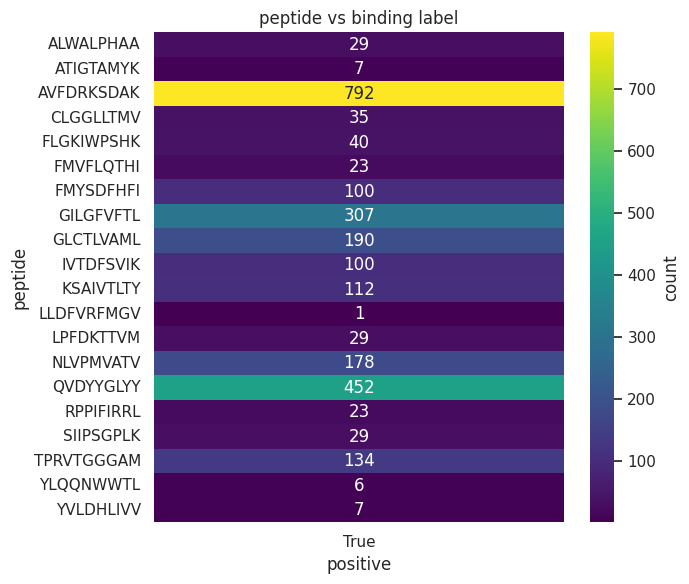

In [ ]:
# Distribution of `type` across the `positive` label as a heatmap
# NaN keys are dropped by default. 
subset_pos = df[df["peptide"].notna() & df["positive"].notna() & (df["positive"] == 1)]

ct = pd.crosstab(subset_pos["peptide"], subset_pos["positive"])

plt.figure(figsize=(7, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="viridis", cbar_kws={"label": "count"})
plt.title("peptide vs binding label")
plt.xlabel("positive"); plt.ylabel("peptide")
plt.tight_layout(); plt.show()

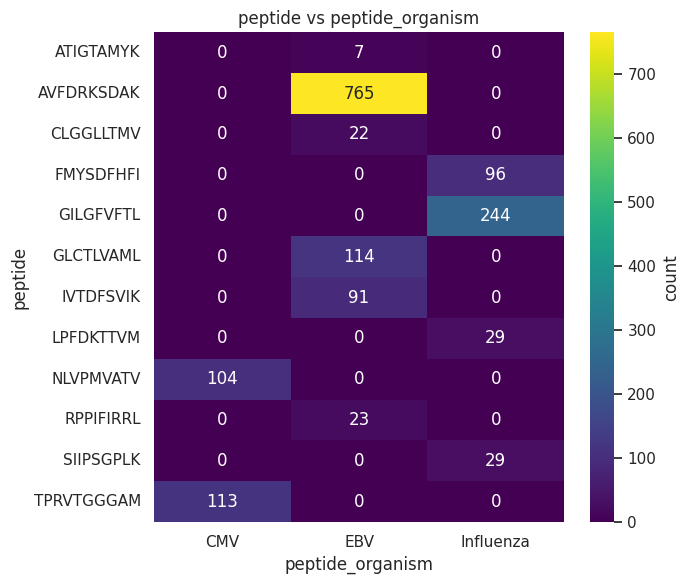

In [ ]:
# Distribution of `type` across the `positive` label as a heatmap
# NaN keys are dropped by default. 
subset_pos = df[df["peptide"].notna() & df["positive"].notna() & (df["positive"] == 1)]

ct = pd.crosstab(subset_pos["peptide"], subset_pos["peptide_organism"])

plt.figure(figsize=(7, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="viridis", cbar_kws={"label": "count"})
plt.title("peptide vs peptide_organism")
plt.xlabel("peptide_organism"); 
plt.ylabel("peptide")
plt.tight_layout(); plt.show()

## 3. Logical column groups

In [22]:
groups = {
    "identity":   ["sample_id", "organism", "mhc_class", "donor_id", "dataset", "type", "positive"],
    "pmhc":       ["mhc", "peptide", "mhc_peptide", "peptide_organism"],
    "tcr_alpha":  ["va", "ja", "cdr3a"],
    "tcr_beta":   ["vb", "jb", "cdr3b"],
    "tcrdock":    ["model_2_ptm_ft4_plddt", "model_2_ptm_ft4_pae", "pmhc_tcr_pae"],
    "pyrosetta":  ["pyrosetta_interface_dG", "pyrosetta_interface_delta_sasa",
                   "pyrosetta_complex_energy", "dSASA_freesasa", "dSASA_ShrakeRupley"],
    "tfold":      ["tfold_ipTM", "tfold_pTM", "tfold_actifptm", "tfold_lDDT_Ca"],
    "boltz":      ["boltz_iptm", "boltz_ptm", "boltz_confidence_score", "boltz_complex_plddt"],
}
for g, cols in groups.items():
    print(f"{g:10s}: {cols}")

identity  : ['sample_id', 'organism', 'mhc_class', 'donor_id', 'dataset', 'type', 'positive']
pmhc      : ['mhc', 'peptide', 'mhc_peptide', 'peptide_organism']
tcr_alpha : ['va', 'ja', 'cdr3a']
tcr_beta  : ['vb', 'jb', 'cdr3b']
tcrdock   : ['model_2_ptm_ft4_plddt', 'model_2_ptm_ft4_pae', 'pmhc_tcr_pae']
pyrosetta : ['pyrosetta_interface_dG', 'pyrosetta_interface_delta_sasa', 'pyrosetta_complex_energy', 'dSASA_freesasa', 'dSASA_ShrakeRupley']
tfold     : ['tfold_ipTM', 'tfold_pTM', 'tfold_actifptm', 'tfold_lDDT_Ca']
boltz     : ['boltz_iptm', 'boltz_ptm', 'boltz_confidence_score', 'boltz_complex_plddt']


## 4. Categorical distributions

In [23]:
def show_counts(col, n=15):
    print(f"\n=== {col}  (nunique={df[col].nunique()}, null={df[col].isna().mean()*100:.0f}%) ===")
    print(df[col].value_counts(dropna=False).head(n).to_string())

for c in ["organism", "mhc_class", "mhc", "positive", "type",
          "peptide_organism", "dataset", "donor_id"]:
    show_counts(c)


=== organism  (nunique=1, null=0%) ===
organism
human    12260

=== mhc_class  (nunique=1, null=0%) ===
mhc_class
1    12260

=== mhc  (nunique=6, null=0%) ===
mhc
A*02:01    5010
A*11:01    3908
B*07:02    1531
A*01:01    1137
C*06:02     671
C*04:01       3

=== positive  (nunique=2, null=0%) ===
positive
False    9666
True     2594

=== type  (nunique=6, null=10%) ===
type
negative_binder    7730
binder             1921
NaN                1268
peptide             670
MHC                 335
randomized          335
negative              1

=== peptide_organism  (nunique=3, null=24%) ===
peptide_organism
EBV          4952
Influenza    3048
NaN          2944
CMV          1316

=== dataset  (nunique=4, null=90%) ===
dataset
NaN                     10992
negative_HIV_CMV_HPV      615
HPV                       564
HIV_CMV                    58
negative_COVID             31

=== donor_id  (nunique=13, null=24%) ===
donor_id
NaN      2944
LP739    2238
LP731    1809
LP696     982
LP648    

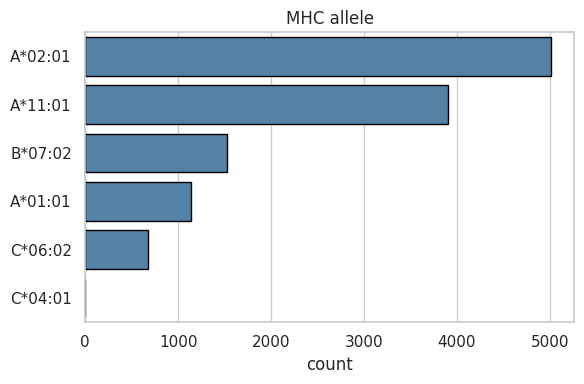

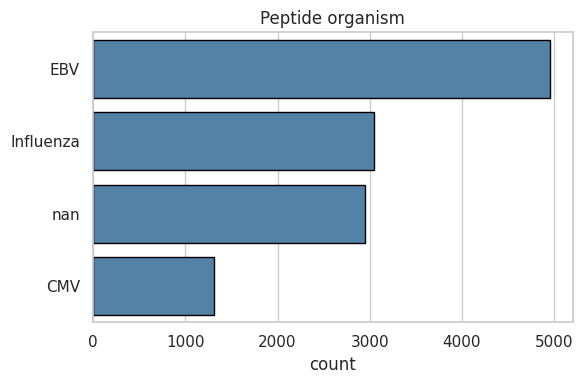

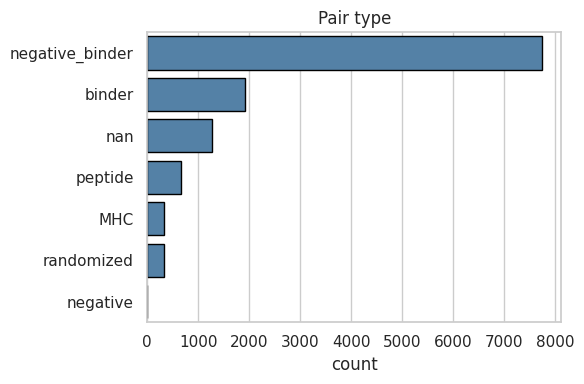

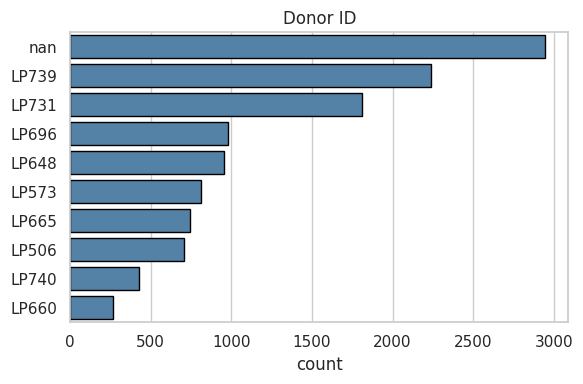

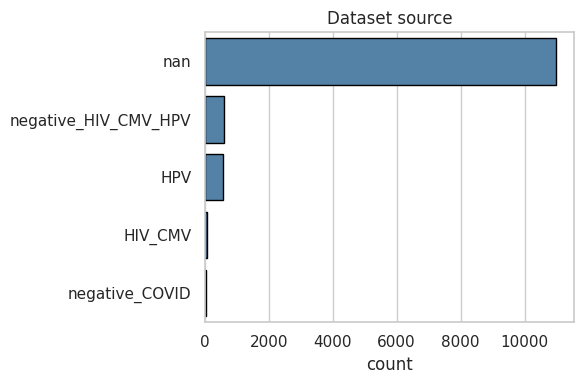

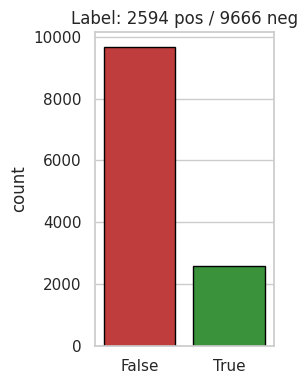

In [28]:
# Each categorical as its own bar plot, single standard color
BAR_COLOR = "steelblue"

def barcat(col, title, n=10, color=BAR_COLOR):
    s = df[col].value_counts(dropna=False).head(n)
    s.index = [str(x) for x in s.index]
    plt.figure(figsize=(6, 4))
    sns.barplot(x=s.values, y=s.index, color=color, edgecolor="black")
    plt.title(title); 
    plt.xlabel("count"); 
    plt.ylabel("")
    plt.tight_layout(); 
    plt.show()

barcat("mhc", "MHC allele")
barcat("peptide_organism", "Peptide organism")
barcat("type", "Pair type")
barcat("donor_id", "Donor ID")
barcat("dataset", "Dataset source")


# Label gets its own red/green coding (binder vs non-binder)
s = df["positive"].value_counts()
plt.figure(figsize=(3, 4))
sns.barplot(x=[str(i) for i in s.index], 
            y=s.values,
            hue=[str(i) for i in s.index], 
            legend=False, 
            edgecolor="black",
            palette=["#d62728", "#2ca02c"])

plt.title(f"Label: {s.get(True, 0)} pos / {s.get(False, 0)} neg"); 
plt.ylabel("count")
plt.tight_layout(); 
plt.show()

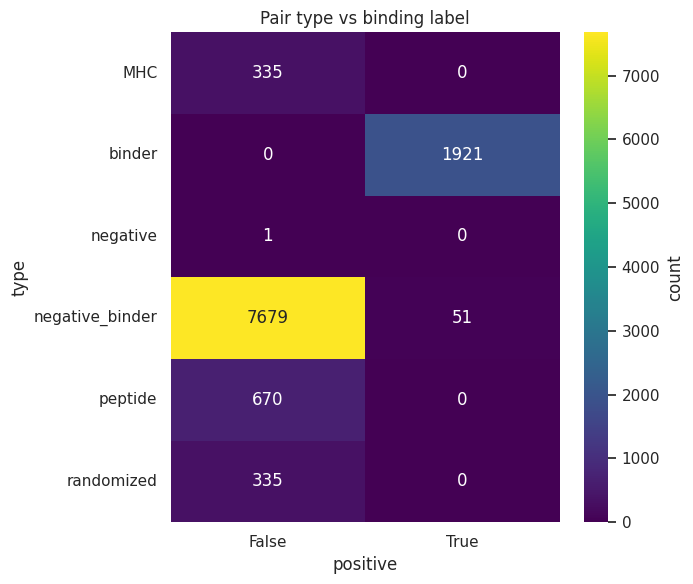

In [65]:
# Distribution of `type` across the `positive` label as a heatmap
ct = pd.crosstab(df["type"], df["positive"])

plt.figure(figsize=(7, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="viridis", cbar_kws={"label": "count"})
plt.title("Pair type vs binding label")
plt.xlabel("positive"); plt.ylabel("type")
plt.tight_layout(); plt.show()

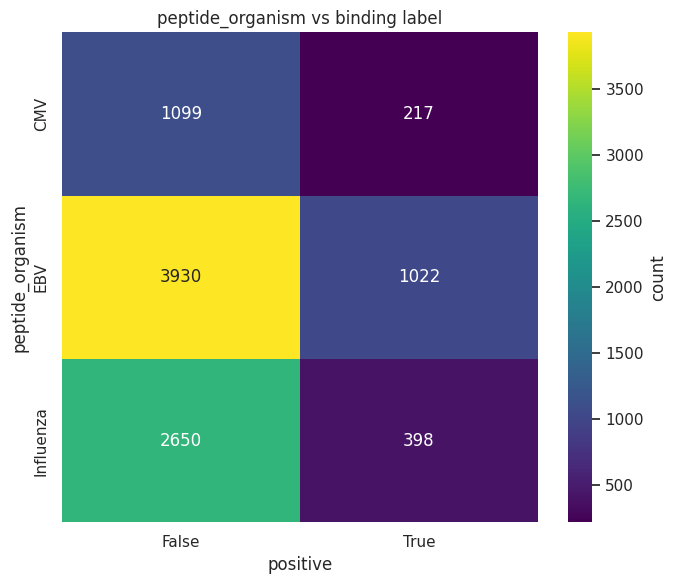

In [67]:
# Distribution of `type` across the `positive` label as a heatmap
# NaN keys are dropped by default. 
#eptide_organism is ~24% null (2,944 rows) → those 2,944 rows are dropped, so the heatmap covers only 9,316 rows, not all 12,260.
ct = pd.crosstab(df["peptide_organism"], df["positive"])

plt.figure(figsize=(7, 6))
sns.heatmap(ct, annot=True, fmt="d", cmap="viridis", cbar_kws={"label": "count"})
plt.title("peptide_organism vs binding label")
plt.xlabel("positive"); plt.ylabel("peptide_organism")
plt.tight_layout(); plt.show()

**Takeaways**
- All rows are human, MHC class I.
- Label is imbalanced (~21% positive) — kept unbalanced on purpose for honest AUPRC evaluation.
- `A*02:01` and `A*11:01` dominate; `C*04:01` has only 3 rows.
- The viral / in-silico additions have no `donor_id` / `dataset` annotation (NaN).

## 5. Sequence features — peptide & CDR3 lengths

Peptide length:
 pep_len
8         1
9     10633
10     1622
11        4

CDR3 length summary:
        cdr3a_len  cdr3b_len
count    12260.0   12260.00
mean        13.5      14.40
std          2.2       1.67
min          5.0       9.00
25%         12.0      13.00
50%         14.0      14.00
75%         15.0      15.00
max         55.0      23.00
Max CDR3-alpha length: 55, Max CDR3-beta length: 23


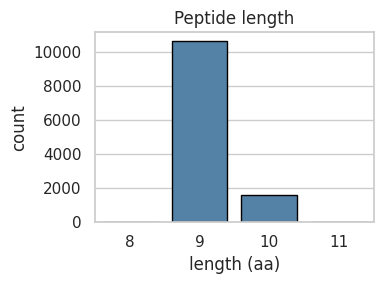

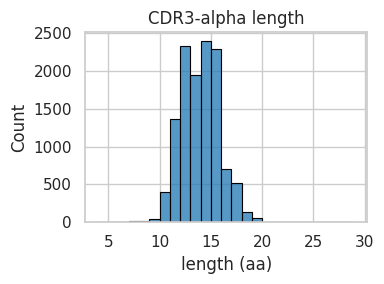

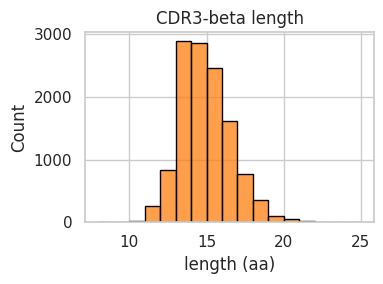

In [33]:
df["pep_len"]   = df["peptide"].str.len()
df["cdr3a_len"]  = df["cdr3a"].str.len()
df["cdr3b_len"]  = df["cdr3b"].str.len()

print("Peptide length:\n", df["pep_len"].value_counts().sort_index().to_string())
print("\nCDR3 length summary:\n", df[["cdr3a_len", "cdr3b_len"]].describe().round(2).to_string())
print(f"Max CDR3-alpha length: {int(df.cdr3a_len.max())}, Max CDR3-beta length: {int(df.cdr3b_len.max())}")

# Peptide length
plt.figure(figsize=(4, 3))
sns.countplot(x="pep_len", data=df, color="steelblue", edgecolor="black")
plt.title("Peptide length"); 
plt.xlabel("length (aa)"); 
plt.ylabel("count")
plt.tight_layout(); 
plt.show()

# CDR3 alpha length
plt.figure(figsize=(4, 3))
sns.histplot(df["cdr3a_len"], bins=range(4, 30), color="#1f77b4", edgecolor="black")
plt.title(f"CDR3-alpha length"); 
plt.xlabel("length (aa)")
plt.tight_layout(); 
plt.show()

# CDR3 beta length
plt.figure(figsize=(4, 3))
sns.histplot(df["cdr3b_len"], bins=range(8, 26), color="#ff7f0e", edgecolor="black")
plt.title("CDR3-beta length"); 
plt.xlabel("length (aa)")
plt.tight_layout(); 
plt.show()

Peptides are overwhelmingly 9-mers (classic MHC-I). Note the long CDR3α outlier worth inspecting:

In [7]:
df.loc[df["cdr3a_len"] > 25, ["cdr3a", "cdr3a_len", "va", "ja", "peptide", "positive"]]

,cdr3a,cdr3a_len,va,ja,peptide,positive
446,CAARLEYGNKLVFGAGTILRVKSSADSREKKSSGDKLTF,39,TRAV29/DV5*01,TRAJ46*01,SIIPSGPLK,False
3556,CAASIQVWGLPESYLWNWNKAPSHPKSWVEIPNTANHFCMGICYSV...,55,TRAV13-1*01,TRAJ11*01,GLCTLVAML,False
4196,CAASIQVWGLPESYLWNWNKAPSHPKSWVEIPNTANHFCMGICYSV...,55,TRAV13-1*01,TRAJ11*01,TPRVTGGGAM,False
5082,CAASIQVWGLPESYLWNWNKAPSHPKSWVEIPNTANHFCMGICYSV...,55,TRAV13-1*01,TRAJ11*01,RPPIFIRRL,True
5424,CAASIQVWGLPESYLWNWNKAPSHPKSWVEIPNTANHFCMGICYSV...,55,TRAV13-1*01,TRAJ11*01,LPFDKTTVM,False
6700,CAARLEYGNKLVFGAGTILRVKSSADSREKKSSGDKLTF,39,TRAV29/DV5*01,TRAJ46*01,IVTDFSVIK,True
8519,CAARLEYGNKLVFGAGTILRVKSSADSREKKSSGDKLTF,39,TRAV29/DV5*01,TRAJ46*01,AVFDRKSDAK,False
9631,CAASIQVWGLPESYLWNWNKAPSHPKSWVEIPNTANHFCMGICYSV...,55,TRAV13-1*01,TRAJ11*01,GILGFVFTL,False
10171,CAARLEYGNKLVFGAGTILRVKSSADSREKKSSGDKLTF,39,TRAV29/DV5*01,TRAJ46*01,ATIGTAMYK,False
10280,CAASIQVWGLPESYLWNWNKAPSHPKSWVEIPNTANHFCMGICYSV...,55,TRAV13-1*01,TRAJ11*01,CLGGLLTMV,False


## 6. V / J gene usage

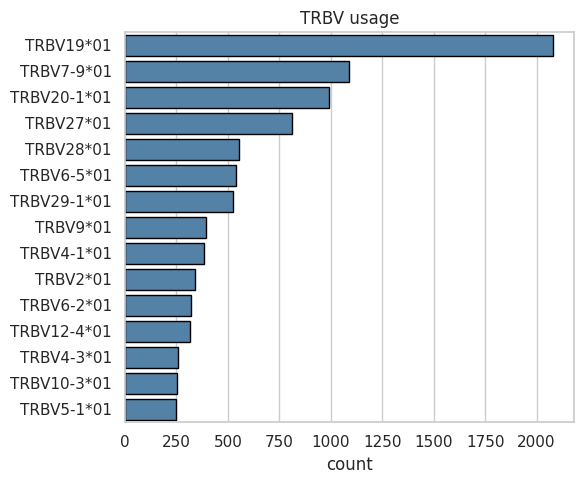

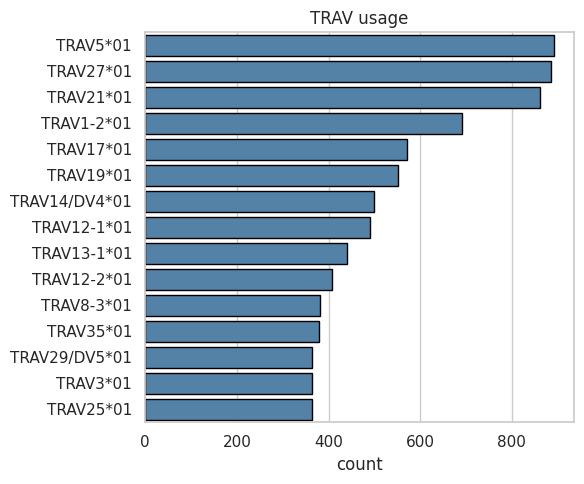

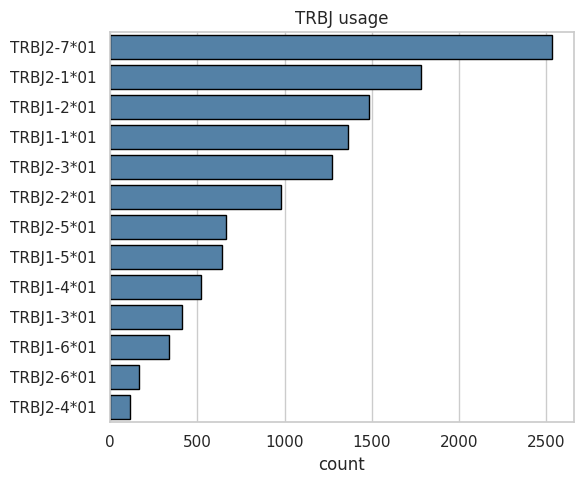

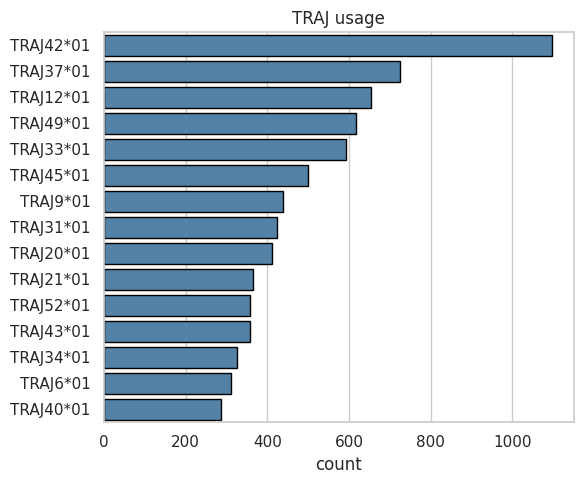

In [34]:
# Each V/J gene usage as its own plot
for col, title in [("vb", "TRBV usage"), ("va", "TRAV usage"),
                   ("jb", "TRBJ usage"), ("ja", "TRAJ usage")]:
    s = df[col].value_counts().head(15)
    plt.figure(figsize=(6, 5))
    sns.barplot(x=s.values, y=s.index, color="steelblue", edgecolor="black")
    plt.title(title); 
    plt.xlabel("count"); 
    plt.ylabel("")
    plt.tight_layout(); 
    plt.show()

## 7. Numeric score summary

In [9]:
score_cols = [
    "model_2_ptm_ft4_plddt", "model_2_ptm_ft4_pae", "pmhc_tcr_pae",
    "pyrosetta_interface_dG", "pyrosetta_interface_delta_sasa", "pyrosetta_complex_energy",
    "dSASA_freesasa", "tfold_ipTM", "tfold_pTM", "tfold_actifptm", "tfold_lDDT_Ca",
    "boltz_iptm", "boltz_ptm", "boltz_confidence_score", "boltz_complex_plddt",
]
df[score_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
model_2_ptm_ft4_plddt,12260.0,91.618,1.519,78.739,90.691,91.611,92.589,96.246
model_2_ptm_ft4_pae,12260.0,5.827,0.793,3.886,5.298,5.741,6.266,12.025
pmhc_tcr_pae,12260.0,7.696,1.343,4.802,6.782,7.494,8.412,15.938
pyrosetta_interface_dG,9316.0,-41.475,9.587,-81.310,-47.745,-40.953,-34.708,-12.355
pyrosetta_interface_delta_sasa,9316.0,1759.313,289.676,733.686,1565.957,1759.339,1955.489,3256.369
pyrosetta_complex_energy,9316.0,-1280.941,22.034,-1358.045,-1295.857,-1281.779,-1267.232,-1176.461
dSASA_freesasa,9316.0,848.533,131.895,362.212,757.987,846.731,934.111,1515.714
tfold_ipTM,5330.0,0.747,0.024,0.663,0.731,0.746,0.764,0.819
tfold_pTM,5330.0,0.791,0.017,0.724,0.779,0.790,0.802,0.858
tfold_actifptm,5330.0,0.556,0.044,0.366,0.528,0.556,0.586,0.690


## 8. Model coverage — how many rows each family scored

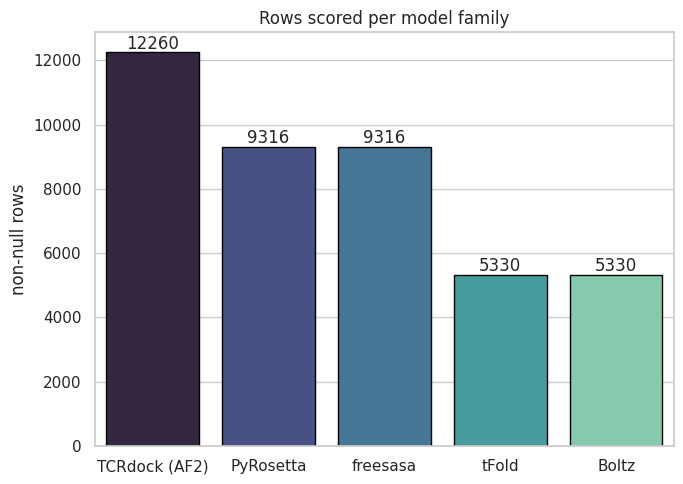

In [42]:
families = {
    "TCRdock (AF2)": "model_2_ptm_ft4_plddt",
    "PyRosetta":     "pyrosetta_interface_dG",
    "freesasa":      "dSASA_freesasa",
    "tFold":         "tfold_ipTM",
    "Boltz":         "boltz_iptm",
}
avail = {k: int(df[v].notna().sum()) for k, v in families.items()}

plt.figure(figsize=(7, 5))
sns.barplot(x=list(avail), y=list(avail.values()), hue=list(avail), 
            legend=False, palette="mako", edgecolor="black")
for i, v in enumerate(avail.values()):
    plt.text(i, v + 100, str(v), ha="center")
#plt.text(3.5, len(df) + 150, f"total = {len(df)}", color="grey")
plt.title("Rows scored per model family"); 
plt.ylabel("non-null rows")
plt.tight_layout(); plt.show()

## 9. do scores separate binders from non-binders?

This is the central benchmark question. We overlay the score distribution for
**binders (green)** vs **non-binders (red)**.

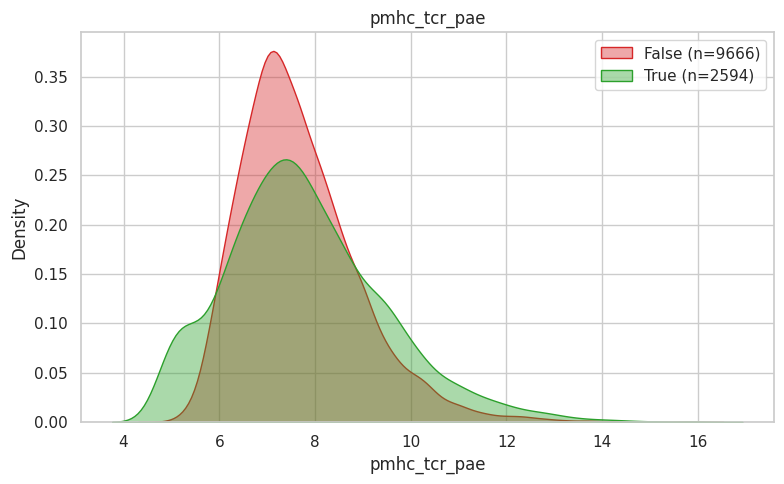

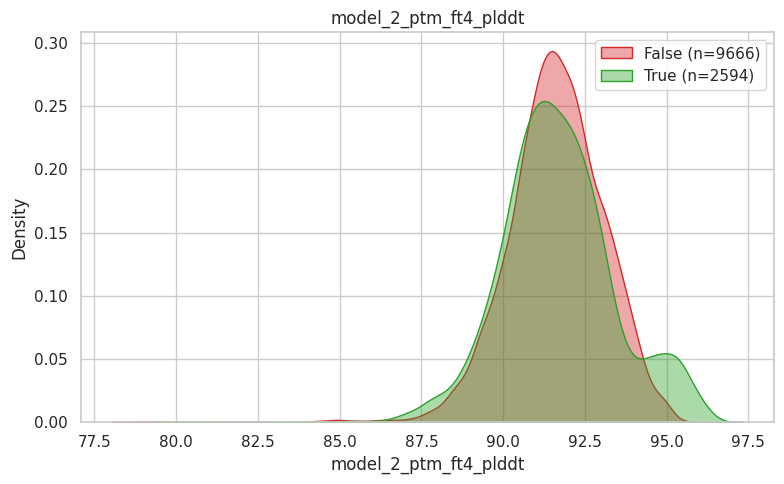

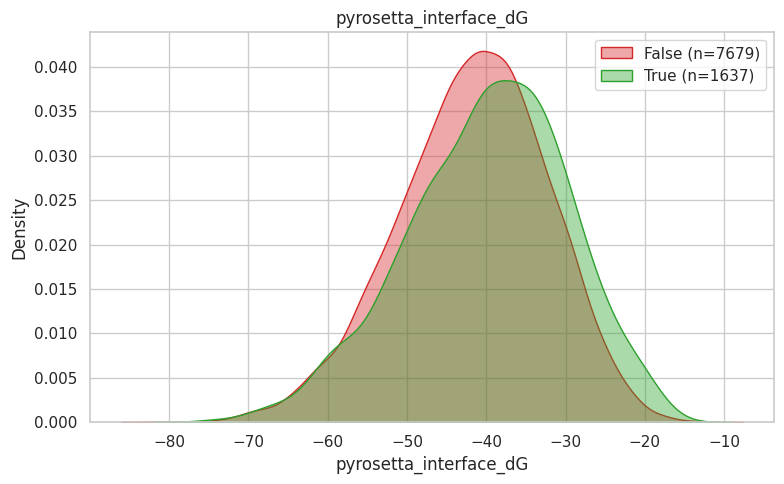

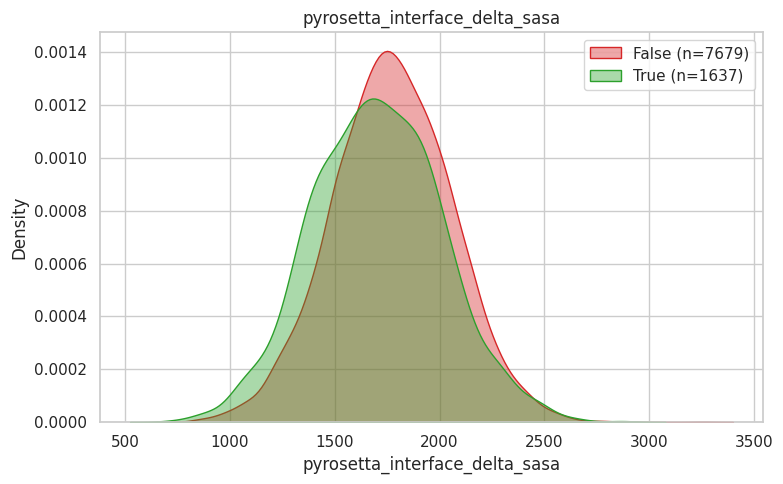

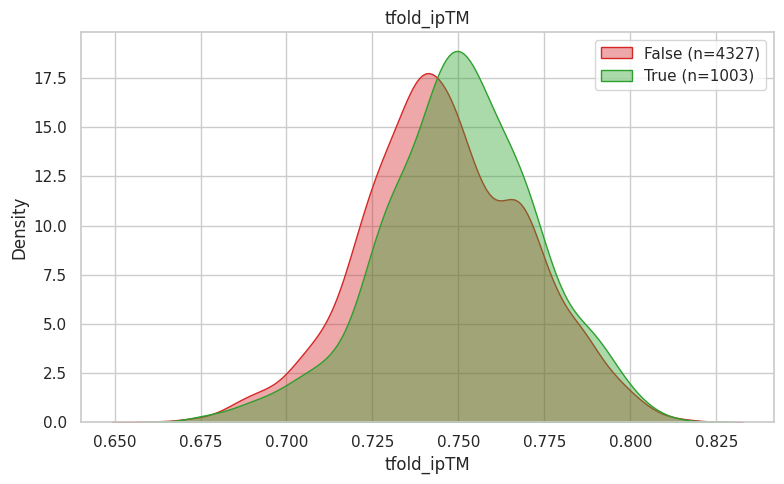

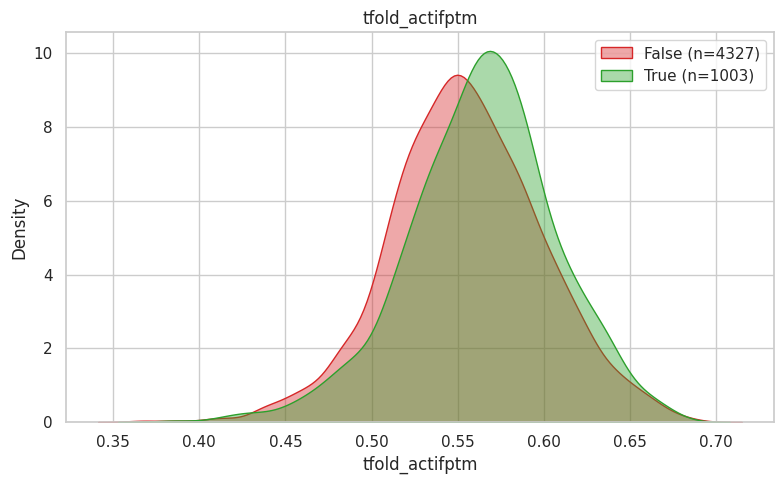

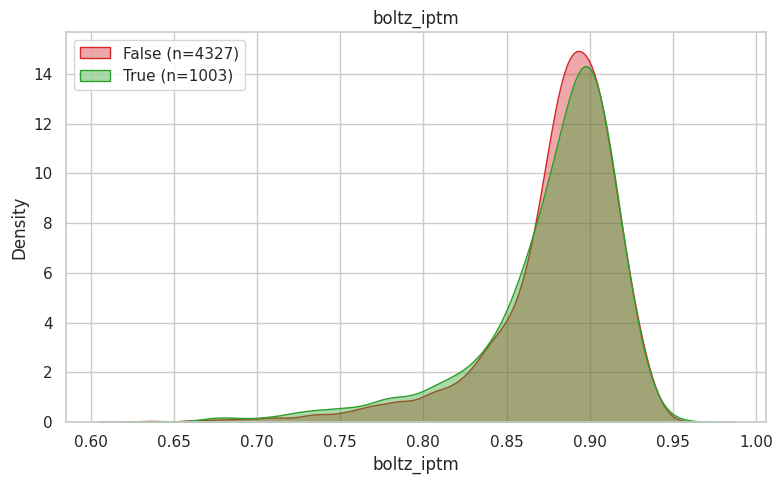

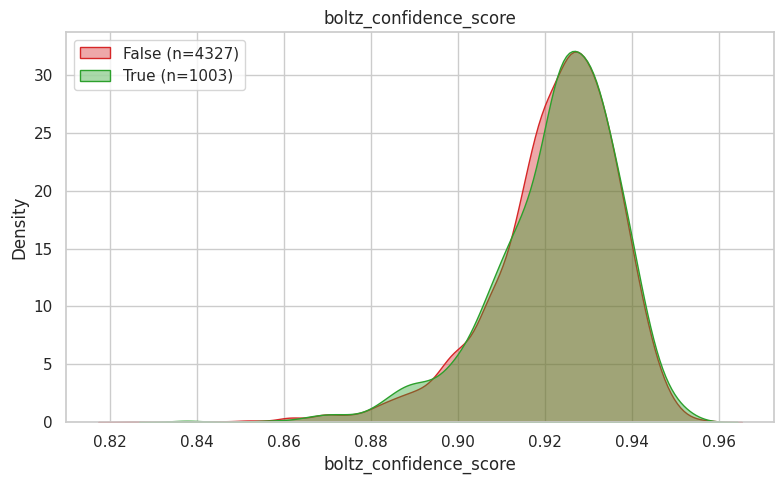

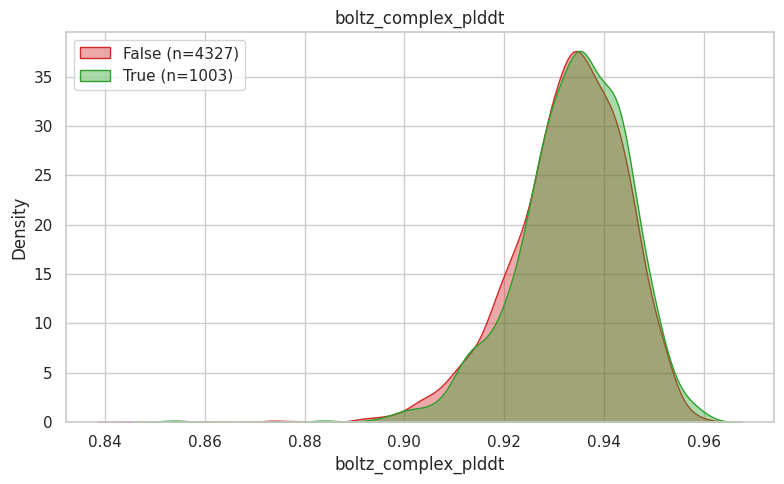

In [44]:
key_scores = ["pmhc_tcr_pae", "model_2_ptm_ft4_plddt", "pyrosetta_interface_dG",
              "pyrosetta_interface_delta_sasa", "tfold_ipTM", "tfold_actifptm",
              "boltz_iptm", "boltz_confidence_score", "boltz_complex_plddt"]

# One distribution plot per score: binder (green) vs non-binder (red)
for c in key_scores:
    plt.figure(figsize=(8, 5))
    for lab, color in [(False, "#d62728"), (True, "#2ca02c")]:
        d = df.loc[df["positive"] == lab, c].dropna()
        if len(d):
            sns.kdeplot(d, fill=True, alpha=0.4, color=color, label=f"{lab} (n={len(d)})")
    plt.title(c); 
    plt.legend()
    plt.tight_layout(); 
    plt.show()

In [45]:
# Quantify the separation: mean by label + univariate AUROC per score
from sklearn.metrics import roc_auc_score

rows = []
for c in key_scores:
    sub = df[[c, "positive"]].dropna()
    # AUROC is direction-agnostic; report max(auc, 1-auc) so lower-is-better scores aren't penalised
    auc = roc_auc_score(sub["positive"], sub[c])
    rows.append({
        "score": c,
        "mean_neg": sub.loc[~sub.positive, c].mean(),
        "mean_pos": sub.loc[sub.positive, c].mean(),
        "auroc": auc,
        "auroc_oriented": max(auc, 1 - auc),
    })
auc_tbl = pd.DataFrame(rows).round(3).sort_values("auroc_oriented", ascending=False)
auc_tbl

,score,mean_neg,mean_pos,auroc,auroc_oriented
3,pyrosetta_interface_delta_sasa,1771.764,1700.904,0.431,0.569
5,tfold_actifptm,0.555,0.564,0.567,0.567
4,tfold_ipTM,0.746,0.750,0.559,0.559
2,pyrosetta_interface_dG,-41.808,-39.909,0.559,0.559
8,boltz_complex_plddt,0.933,0.934,0.523,0.523
0,pmhc_tcr_pae,7.670,7.794,0.517,0.517
6,boltz_iptm,0.879,0.876,0.488,0.512
1,model_2_ptm_ft4_plddt,91.606,91.661,0.494,0.506
7,boltz_confidence_score,0.922,0.922,0.505,0.505


Univariate AUROCs hover near 0.5 → **off-the-shelf structure-confidence scores are near-random
discriminators on this benchmark**, consistent with the difficulty of novel-peptide generalisation.

## 10. Score correlation structure

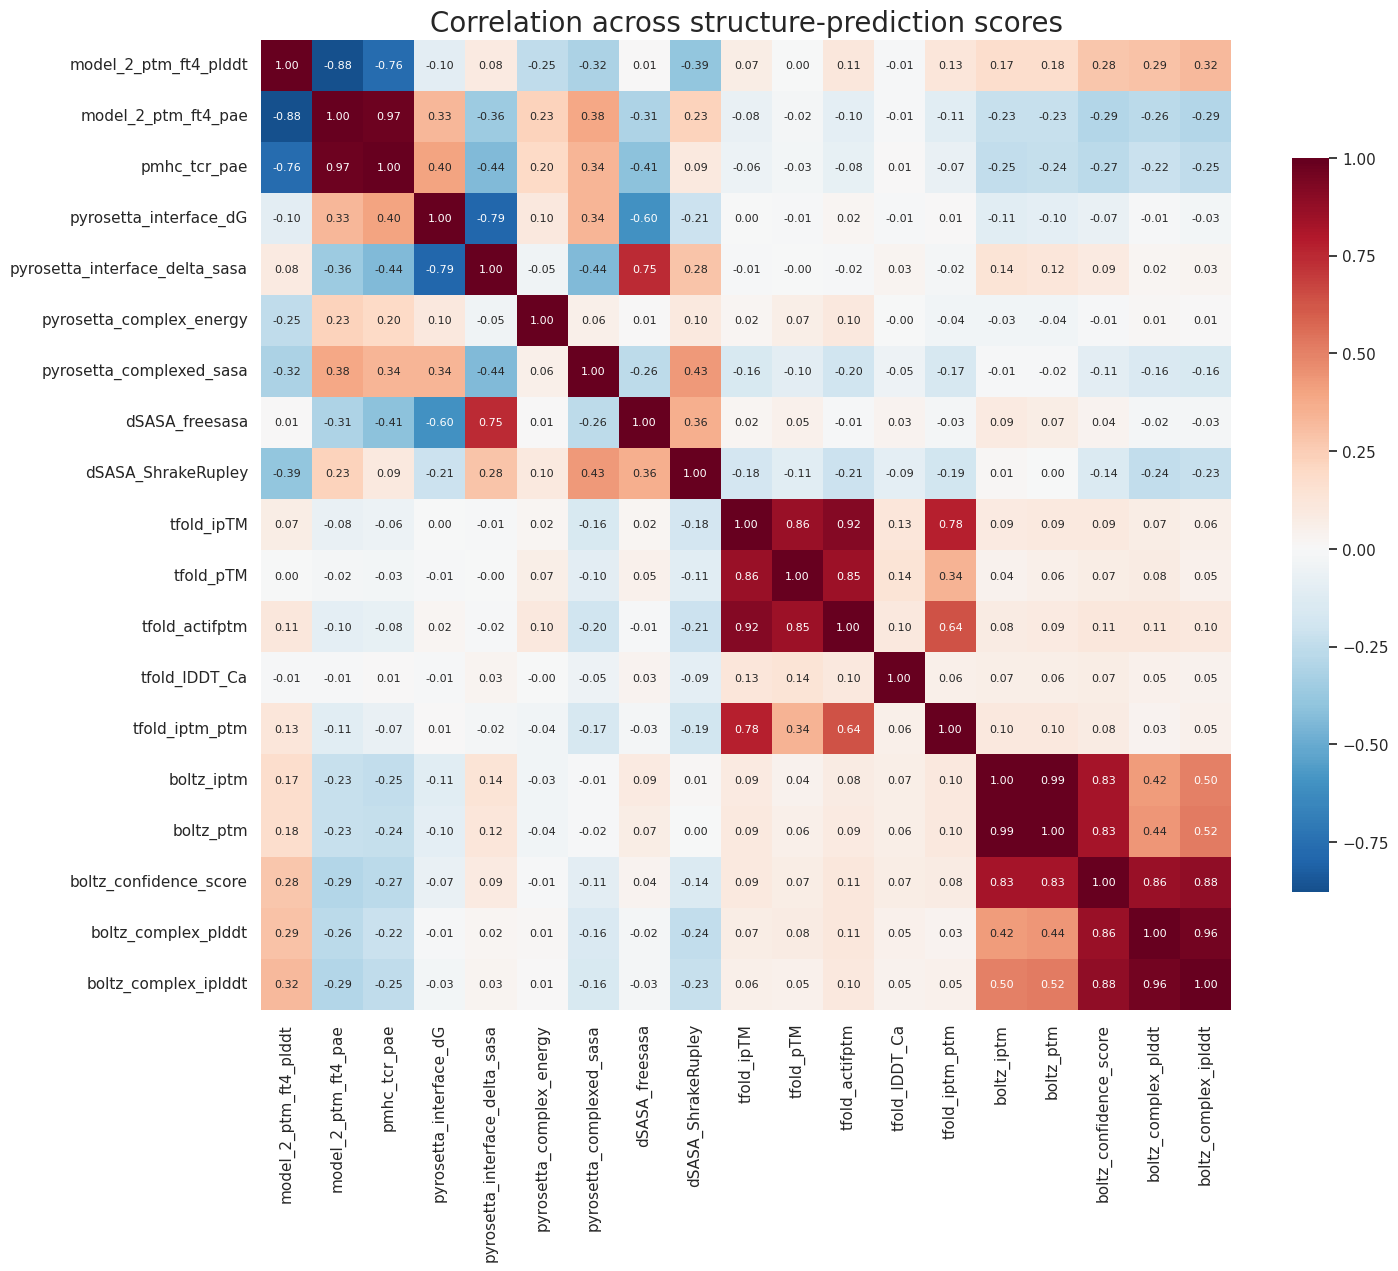

In [46]:
all_num = [
    "model_2_ptm_ft4_plddt", "model_2_ptm_ft4_pae", "pmhc_tcr_pae",
    "pyrosetta_interface_dG", "pyrosetta_interface_delta_sasa", "pyrosetta_complex_energy",
    "pyrosetta_complexed_sasa", "dSASA_freesasa", "dSASA_ShrakeRupley",
    "tfold_ipTM", "tfold_pTM", "tfold_actifptm", "tfold_lDDT_Ca", "tfold_iptm_ptm",
    "boltz_iptm", "boltz_ptm", "boltz_confidence_score", "boltz_complex_plddt", "boltz_complex_iplddt",
]
plt.figure(figsize=(15, 13))
sns.heatmap(df[all_num].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, annot_kws={"size": 8}, cbar_kws={"shrink": 0.7})
plt.title("Correlation across structure-prediction scores", fontsize=20)
plt.tight_layout(); plt.show()

## 11. Label balance across key groupings

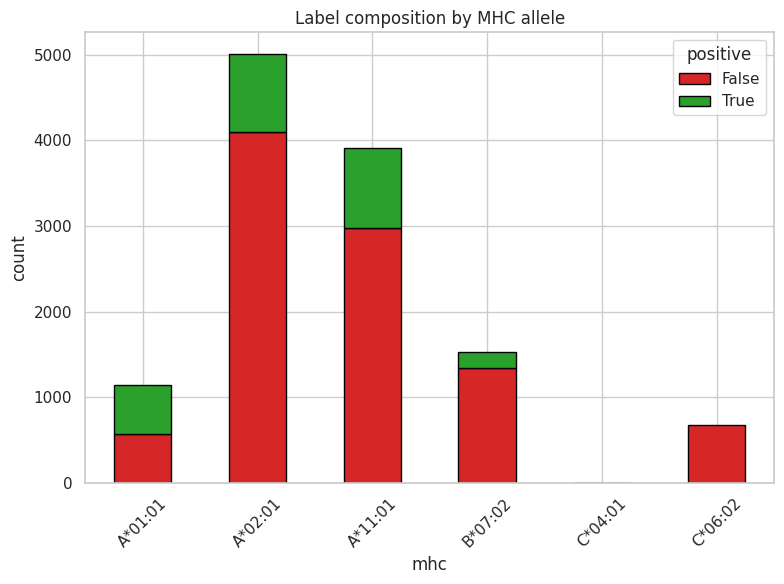

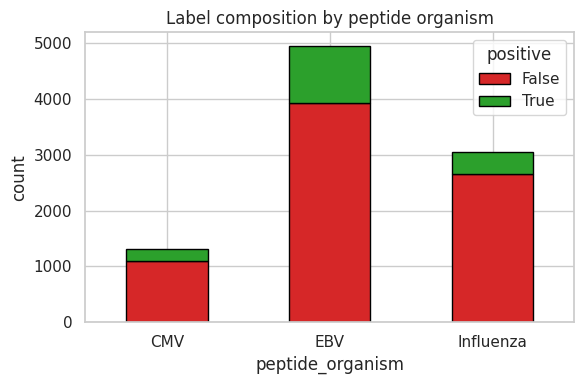

In [50]:
# Label composition by MHC allele
plt.figure(figsize=(8, 6))
pd.crosstab(df["mhc"], df["positive"]).plot(
    kind="bar", stacked=True, color=["#d62728", "#2ca02c"], 
    ax=plt.gca(), 
    edgecolor="black")
plt.title("Label composition by MHC allele"); 
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout(); 
plt.show()

# Label composition by peptide organism
plt.figure(figsize=(6, 4))
pd.crosstab(df["peptide_organism"], df["positive"]).plot(
    kind="bar", stacked=True, color=["#d62728", "#2ca02c"], 
    ax=plt.gca(),
    edgecolor="black")
plt.title("Label composition by peptide organism"); plt.ylabel("count")
plt.xticks(rotation=0)
plt.tight_layout(); 
plt.show()

In [15]:
# Positive rate per group (numeric)
for col in ["mhc", "peptide_organism", "donor_id"]:
    print(f"\n=== positive rate by {col} ===")
    g = df.groupby(col)["positive"].agg(["mean", "count"]).round(3)
    print(g.sort_values("mean", ascending=False).to_string())


=== positive rate by mhc ===
          mean  count
mhc                  
A*01:01  0.496   1137
A*11:01  0.237   3908
A*02:01  0.183   5010
B*07:02  0.121   1531
C*04:01  0.000      3
C*06:02  0.000    671

=== positive rate by peptide_organism ===
                   mean  count
peptide_organism              
EBV               0.206   4952
CMV               0.165   1316
Influenza         0.131   3048

=== positive rate by donor_id ===
           mean  count
donor_id              
LP660     0.265    264
LP739     0.255   2238
LP506     0.251    704
LP679     0.250     56
LP520     0.200     95
LP702     0.200    230
LP665     0.168    743
LP740     0.151    424
LP648     0.127    954
LP700     0.125      8
LP731     0.120   1809
LP696     0.119    982
LP573     0.117    809


## 12. Split-relevant structure (from `bench_notes.txt`)

Honest evaluation requires grouped splits. Quick diagnostics on the units we'd split over:
unique donors, peptides, and TCR clonotypes, plus how peptides distribute across donors.

In [16]:
df["clonotype"] = df[["va", "ja", "cdr3a", "vb", "jb", "cdr3b"]].astype(str).agg("|".join, axis=1)

print("Unique donors          :", df["donor_id"].nunique())
print("Unique peptides        :", df["peptide"].nunique())
print("Unique TCR clonotypes  :", df["clonotype"].nunique())
print("Rows / clonotype (max) :", df["clonotype"].value_counts().max())

# how many distinct peptides each donor saw
print("\nDistinct peptides per donor:")
print(df.groupby("donor_id")["peptide"].nunique().sort_values(ascending=False).to_string())

Unique donors          : 13
Unique peptides        : 668
Unique TCR clonotypes  : 2389
Rows / clonotype (max) : 40

Distinct peptides per donor:
donor_id
LP731    9
LP648    8
LP700    8
LP665    8
LP573    8
LP740    8
LP696    8
LP520    5
LP660    5
LP702    5
LP506    4
LP679    4
LP739    4


---
### Summary

- **12,260 TCR–pMHC pairs**, ~21% positive, human MHC-I, 668 peptides, 6 alleles.
- Four scoring families with block-structured coverage (TCRdock 100%, PyRosetta 76%, tFold/Boltz 43%).
- **Structure-confidence scores barely separate binders from non-binders** (univariate AUROC ≈ 0.5).
- Data carries donor / peptide / clonotype structure — use grouped splits (leave-one-donor-out,
  leave-one-peptide-out) per `bench_notes.txt`, not random splits.